# S&P 500 Feature Engineering for a Student-t HMM

This notebook builds a heavy-tail-aware, multi-horizon feature matrix from daily S&P 500 and VIX data using `yfinance`.

Design principle: preserve crisis behavior, volatility clustering, and fat tails instead of Gaussian-style over-smoothing.

In [2]:
import warnings
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
from sklearn.feature_selection import mutual_info_regression
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy import stats
from scipy.spatial.distance import squareform

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
sns.set_theme(style="white")

SHORT_WINDOWS = [5, 10, 20]
MEDIUM_WINDOWS = [60]
LONG_WINDOWS = [120, 252]
WINDOWS = SHORT_WINDOWS + MEDIUM_WINDOWS + LONG_WINDOWS
TRADING_DAYS = 252
MILD_CLIP_Q = 0.005


def _extract_ticker_frame(raw: pd.DataFrame, ticker: str, fields: Iterable[str]) -> pd.DataFrame:
    """Handle the different yfinance MultiIndex layouts and return one ticker's OHLCV frame."""
    if isinstance(raw.columns, pd.MultiIndex):
        level0 = set(raw.columns.get_level_values(0))
        level1 = set(raw.columns.get_level_values(1))

        if ticker in level0:
            frame = raw[ticker].copy()
        elif ticker in level1:
            frame = raw.xs(ticker, axis=1, level=1).copy()
        else:
            raise KeyError(f"Ticker {ticker} not found in downloaded data.")
    else:
        frame = raw.copy()

    frame = frame.rename(columns=str)
    missing = [field for field in fields if field not in frame.columns]
    if missing:
        raise KeyError(f"Missing fields for {ticker}: {missing}")
    return frame.loc[:, list(fields)].copy()


def download_market_data() -> pd.DataFrame:
    """Download the full daily history for S&P 500 and VIX, align dates, and forward-fill sparse gaps."""
    tickers = ["^GSPC", "^VIX"]
    fields = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]

    raw = yf.download(
        tickers=tickers,
        period="max",
        interval="1d",
        auto_adjust=False,
        progress=False,
        threads=False,
    )

    if raw.empty:
        raise ValueError(
            "yfinance returned no rows for ^GSPC/^VIX. This is usually a network issue or a system-date issue. "
            "If your machine clock is set far into the future, Yahoo requests can fail and produce an empty dataset."
        )

    spx = _extract_ticker_frame(raw, "^GSPC", fields).add_prefix("spx_")
    vix = _extract_ticker_frame(raw, "^VIX", fields).add_prefix("vix_")

    data = spx.join(vix, how="inner").sort_index()
    data.index = pd.to_datetime(data.index)

    numeric_cols = data.select_dtypes(include=[np.number]).columns
    data[numeric_cols] = data[numeric_cols].ffill()

    if data.empty:
        raise ValueError("Aligned market dataset is empty after joining ^GSPC and ^VIX.")

    return data


def mild_clip(series: pd.Series, lower_q: float = MILD_CLIP_Q, upper_q: float = 1 - MILD_CLIP_Q) -> pd.Series:
    """Optional numerical guardrail only; the default workflow leaves tails intact."""
    lower = series.quantile(lower_q)
    upper = series.quantile(upper_q)
    return series.clip(lower=lower, upper=upper)


def rolling_slope(series: pd.Series, window: int) -> pd.Series:
    """Linear trend slope inside each window; useful for persistent regime direction."""
    x = np.arange(window, dtype=float)

    def _slope(values: np.ndarray) -> float:
        return float(stats.linregress(x, values).slope)

    return series.rolling(window).apply(_slope, raw=True)


def rolling_autocorr_lag1(series: pd.Series, window: int) -> pd.Series:
    """Lag-1 autocorrelation of a rolling series, used here for squared returns persistence."""
    def _autocorr(values: np.ndarray) -> float:
        if np.allclose(values.std(ddof=0), 0.0):
            return np.nan
        return float(pd.Series(values).autocorr(lag=1))

    return series.rolling(window).apply(_autocorr, raw=True)


def rolling_expected_shortfall(returns: pd.Series, window: int, alpha: float = 0.05) -> pd.Series:
    """Historical Expected Shortfall keeps tail losses visible instead of suppressing them."""
    def _es(values: np.ndarray) -> float:
        cutoff = np.quantile(values, alpha)
        tail = values[values <= cutoff]
        return float(tail.mean()) if len(tail) else np.nan

    return returns.rolling(window).apply(_es, raw=True)


def rolling_up_down_ratio(returns: pd.Series, window: int) -> pd.Series:
    def _ratio(values: np.ndarray) -> float:
        up = np.sum(values > 0)
        down = np.sum(values < 0)
        return float(up / down) if down > 0 else np.nan

    return returns.rolling(window).apply(_ratio, raw=True)


def build_base_series(data: pd.DataFrame) -> pd.DataFrame:
    """Create the core stationary and heavy-tail-aware building blocks."""
    out = data.copy()

    out["spx_price"] = out["spx_Adj Close"].replace(0, np.nan)
    out["vix_price"] = out["vix_Adj Close"].replace(0, np.nan)

    out["return_log"] = np.log(out["spx_price"]).diff()
    out["return_abs"] = out["return_log"].abs()
    out["return_sq"] = out["return_log"] ** 2

    out["vix_return_log"] = np.log(out["vix_price"]).diff()

    intraday_range = np.log(out["spx_High"] / out["spx_Low"])
    out["range_log"] = intraday_range.replace([np.inf, -np.inf], np.nan)

    out["amihud_raw"] = out["return_abs"] / out["spx_Volume"].replace(0, np.nan)

    return out


def compute_return_features(base: pd.DataFrame, windows: Iterable[int]) -> pd.DataFrame:
    returns = base["return_log"]
    log_price = np.log(base["spx_price"])
    feats = {}

    for window in windows:
        roll_max = log_price.rolling(window).max()
        drawdown = log_price - roll_max

        feats[f"returns_mean_{window}"] = returns.rolling(window).mean()
        feats[f"returns_cumulative_{window}"] = returns.rolling(window).sum()
        feats[f"drawdown_current_{window}"] = drawdown
        feats[f"drawdown_max_{window}"] = drawdown.rolling(window).min()

    return pd.DataFrame(feats, index=base.index)


def compute_volatility_features(base: pd.DataFrame, windows: Iterable[int]) -> pd.DataFrame:
    returns = base["return_log"]
    abs_returns = base["return_abs"]
    sq_returns = base["return_sq"]
    feats = {}

    for window in windows:
        realized_std = returns.rolling(window).std()
        realized_var = returns.rolling(window).var()

        feats[f"volatility_std_{window}"] = realized_std
        feats[f"volatility_variance_{window}"] = realized_var
        feats[f"volatility_of_vol_{window}"] = realized_std.rolling(window).std()
        feats[f"volatility_sqret_autocorr1_{window}"] = rolling_autocorr_lag1(sq_returns, window)
        feats[f"volatility_absret_mean_{window}"] = abs_returns.rolling(window).mean()

    return pd.DataFrame(feats, index=base.index)


def compute_vix_features(base: pd.DataFrame, vol_feats: pd.DataFrame, windows: Iterable[int]) -> pd.DataFrame:
    vix_level = base["vix_price"]
    vix_returns = base["vix_return_log"]
    feats = {
        "vix_level_1": vix_level,
        "vix_returns_1": vix_returns,
    }

    for window in windows:
        feats[f"vix_mean_{window}"] = vix_level.rolling(window).mean()
        feats[f"vix_std_{window}"] = vix_level.rolling(window).std()
        realized_vol = vol_feats[f"volatility_std_{window}"].replace(0, np.nan)
        feats[f"vix_to_realizedvol_{window}"] = vix_level / (np.sqrt(TRADING_DAYS) * realized_vol)

    return pd.DataFrame(feats, index=base.index)


def compute_distribution_features(base: pd.DataFrame, windows: Iterable[int]) -> pd.DataFrame:
    returns = base["return_log"]
    feats = {}

    for window in windows:
        downside = returns.clip(upper=0)
        upside = returns.clip(lower=0)

        q95 = returns.rolling(window).quantile(0.95)
        q05 = returns.rolling(window).quantile(0.05)

        feats[f"distribution_skew_{window}"] = returns.rolling(window).skew()
        feats[f"distribution_kurtosis_{window}"] = returns.rolling(window).kurt()
        feats[f"distribution_downside_semivariance_{window}"] = (downside ** 2).rolling(window).mean()
        feats[f"distribution_upside_semivariance_{window}"] = (upside ** 2).rolling(window).mean()
        feats[f"distribution_tail_ratio_{window}"] = q95 / q05.replace(0, np.nan)

    return pd.DataFrame(feats, index=base.index)


def compute_momentum_features(base: pd.DataFrame, windows: Iterable[int]) -> pd.DataFrame:
    returns = base["return_log"]
    price = base["spx_price"]
    feats = {}

    for window in windows:
        ma = price.rolling(window).mean()
        std = returns.rolling(window).std().replace(0, np.nan)

        feats[f"momentum_cumulative_{window}"] = returns.rolling(window).sum()
        feats[f"trend_slope_{window}"] = rolling_slope(np.log(price), window)
        feats[f"sharpe_rolling_{window}"] = returns.rolling(window).mean() / std
        feats[f"price_to_ma_{window}"] = price / ma - 1.0

    long_anchor = max(windows)
    long_ma = price.rolling(long_anchor).mean()
    for window in windows:
        short_ma = price.rolling(window).mean()
        if window != long_anchor:
            feats[f"ma_spread_{window}_{long_anchor}"] = short_ma / long_ma - 1.0

    return pd.DataFrame(feats, index=base.index)


def compute_liquidity_features(base: pd.DataFrame, windows: Iterable[int]) -> pd.DataFrame:
    volume = base["spx_Volume"].replace(0, np.nan)
    returns_abs = base["return_abs"]
    amihud = base["amihud_raw"]
    feats = {}

    for window in windows:
        avg_volume = volume.rolling(window).mean()
        feats[f"liquidity_volume_mean_{window}"] = avg_volume
        feats[f"liquidity_volume_shock_{window}"] = volume / avg_volume
        feats[f"liquidity_amihud_{window}"] = amihud.rolling(window).mean()
        feats[f"liquidity_absret_to_volume_{window}"] = returns_abs.rolling(window).sum() / volume.rolling(window).sum()

    return pd.DataFrame(feats, index=base.index)


def compute_breadth_features(base: pd.DataFrame, windows: Iterable[int]) -> pd.DataFrame:
    returns = base["return_log"]
    feats = {}

    for window in windows:
        feats[f"breadth_positive_days_pct_{window}"] = (returns > 0).rolling(window).mean()
        feats[f"breadth_up_down_ratio_{window}"] = rolling_up_down_ratio(returns, window)

    return pd.DataFrame(feats, index=base.index)


def compute_tail_risk_features(base: pd.DataFrame, windows: Iterable[int]) -> pd.DataFrame:
    returns = base["return_log"]
    abs_returns = base["return_abs"]
    feats = {}

    for window in windows:
        rolling_std = returns.rolling(window).std()
        threshold = 2.0 * rolling_std

        feats[f"tail_var_{window}"] = returns.rolling(window).quantile(0.05)
        feats[f"tail_expected_shortfall_{window}"] = rolling_expected_shortfall(returns, window, alpha=0.05)
        feats[f"tail_max_abs_return_{window}"] = abs_returns.rolling(window).max()
        feats[f"tail_extreme_count_{window}"] = (abs_returns > threshold).rolling(window).sum()

    return pd.DataFrame(feats, index=base.index)


def compute_correlation_features(base: pd.DataFrame, vol_feats: pd.DataFrame, windows: Iterable[int]) -> pd.DataFrame:
    returns = base["return_log"]
    vix_returns = base["vix_return_log"]
    feats = {}

    for window in windows:
        realized_std = vol_feats[f"volatility_std_{window}"]
        feats[f"correlation_return_vix_{window}"] = returns.rolling(window).corr(vix_returns)
        feats[f"correlation_return_vol_{window}"] = returns.rolling(window).corr(realized_std)
        feats[f"correlation_leverage_effect_{window}"] = returns.rolling(window).corr(realized_std.diff())

    return pd.DataFrame(feats, index=base.index)


def compute_shock_features(base: pd.DataFrame, vol_feats: pd.DataFrame, windows: Iterable[int]) -> pd.DataFrame:
    returns = base["return_log"]
    abs_returns = base["return_abs"]
    feats = {}

    for window in windows:
        rolling_std = returns.rolling(window).std()
        realized_std = vol_feats[f"volatility_std_{window}"]
        vol_90 = realized_std.rolling(window).quantile(0.90)

        feats[f"shock_absret_gt_2p5std_{window}"] = (abs_returns > (2.5 * rolling_std)).astype(float)
        feats[f"shock_vol_spike_{window}"] = (realized_std > vol_90).astype(float)

    return pd.DataFrame(feats, index=base.index)


def robust_rolling_scale(features: pd.DataFrame, windows: Iterable[int]) -> pd.DataFrame:
    """Robust scaling by rolling median and IQR preserves tail ranking better than z-scores."""
    scaled = pd.DataFrame(index=features.index)
    anchor_window = max(windows)

    for column in features.columns:
        series = features[column]
        median = series.rolling(anchor_window).median()
        q75 = series.rolling(anchor_window).quantile(0.75)
        q25 = series.rolling(anchor_window).quantile(0.25)
        iqr = q75 - q25

        global_iqr = series.quantile(0.75) - series.quantile(0.25)
        if pd.isna(global_iqr) or global_iqr == 0:
            scaled[f"{column}_robust"] = series - median
        else:
            safe_iqr = iqr.where(iqr > 0, global_iqr)
            scaled[f"{column}_robust"] = (series - median) / safe_iqr

    return scaled


def build_feature_matrix(data: pd.DataFrame, windows: Iterable[int]) -> pd.DataFrame:
    if data.empty:
        raise ValueError("Input market data is empty; feature matrix cannot be constructed.")

    base = build_base_series(data)

    returns_df = compute_return_features(base, windows)
    vol_df = compute_volatility_features(base, windows)
    vix_df = compute_vix_features(base, vol_df, windows)
    dist_df = compute_distribution_features(base, windows)
    momentum_df = compute_momentum_features(base, windows)
    liquidity_df = compute_liquidity_features(base, windows)
    breadth_df = compute_breadth_features(base, windows)
    tail_df = compute_tail_risk_features(base, windows)
    corr_df = compute_correlation_features(base, vol_df, windows)
    shock_df = compute_shock_features(base, vol_df, windows)

    raw_features = pd.concat(
        [
            returns_df,
            vol_df,
            vix_df,
            dist_df,
            momentum_df,
            liquidity_df,
            breadth_df,
            tail_df,
            corr_df,
            shock_df,
        ],
        axis=1,
    )

    robust_scaled = robust_rolling_scale(raw_features, windows)
    X = pd.concat([raw_features, robust_scaled], axis=1)
    X = X.replace([np.inf, -np.inf], np.nan)

    all_nan_columns = X.columns[X.isna().all()]
    if len(all_nan_columns) > 0:
        X = X.drop(columns=all_nan_columns)

    X = X.dropna()

    return X


def compute_mutual_information_matrix(X: pd.DataFrame, random_state: int = 42) -> pd.DataFrame:
    """Estimate a symmetric pairwise mutual information matrix for redundancy diagnostics."""
    values = X.to_numpy(dtype=float)
    n_features = values.shape[1]
    mi_matrix = np.zeros((n_features, n_features), dtype=float)

    for i in range(n_features):
        mi_matrix[i, i] = 1.0
        for j in range(i + 1, n_features):
            mi_ij = mutual_info_regression(
                values[:, [i]],
                values[:, j],
                discrete_features=False,
                random_state=random_state,
            )[0]
            mi_ji = mutual_info_regression(
                values[:, [j]],
                values[:, i],
                discrete_features=False,
                random_state=random_state,
            )[0]
            mi_sym = 0.5 * (mi_ij + mi_ji)
            mi_matrix[i, j] = mi_sym
            mi_matrix[j, i] = mi_sym

    mi_df = pd.DataFrame(mi_matrix, index=X.columns, columns=X.columns)
    return mi_df


def extract_high_correlation_pairs(corr: pd.DataFrame, threshold: float = 0.85) -> pd.DataFrame:
    """Collect highly correlated feature pairs from the upper triangle only."""
    upper_mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
    upper = corr.where(upper_mask)
    pairs = (
        upper.stack()
        .rename("correlation")
        .reset_index()
        .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
    )
    pairs = pairs.loc[pairs["correlation"].abs() > threshold].sort_values("correlation", key=lambda s: s.abs(), ascending=False)
    return pairs.reset_index(drop=True)


def plot_matrix_heatmap(matrix: pd.DataFrame, title: str, cmap: str = "coolwarm", center: float | None = 0.0, figsize_scale: float = 0.22):
    """Plot a manageable heatmap with feature labels scaled to matrix size."""
    size = len(matrix.columns)
    fig_size = max(12, min(30, size * figsize_scale))
    plt.figure(figsize=(fig_size, fig_size))
    sns.heatmap(matrix, cmap=cmap, center=center, xticklabels=False, yticklabels=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_feature_dendrogram(distance_matrix: pd.DataFrame, title: str = "Feature Dendrogram"):
    """Cluster features by a precomputed distance matrix and plot the hierarchy."""
    condensed = squareform(distance_matrix.to_numpy(), checks=False)
    linkage_matrix = linkage(condensed, method="ward")
    plt.figure(figsize=(18, 8))
    dendrogram(linkage_matrix, labels=distance_matrix.index.tolist(), leaf_rotation=90, leaf_font_size=8)
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return linkage_matrix


data = download_market_data()
X = build_feature_matrix(data, WINDOWS)

print(f"Downloaded rows: {len(data):,}")
print(f"Feature matrix shape: {X.shape}")
print(f"Date range: {X.index.min().date()} to {X.index.max().date()}")

X.head()

Downloaded rows: 24,695
Feature matrix shape: (439, 446)
Date range: 2002-05-28 to 2023-05-23


,returns_mean_5,returns_cumulative_5,drawdown_current_5,drawdown_max_5,returns_mean_10,returns_cumulative_10,drawdown_current_10,drawdown_max_10,returns_mean_20,returns_cumulative_20,drawdown_current_20,drawdown_max_20,returns_mean_60,returns_cumulative_60,drawdown_current_60,drawdown_max_60,returns_mean_120,returns_cumulative_120,drawdown_current_120,drawdown_max_120,returns_mean_252,returns_cumulative_252,drawdown_current_252,drawdown_max_252,volatility_std_5,volatility_variance_5,volatility_of_vol_5,volatility_sqret_autocorr1_5,volatility_absret_mean_5,volatility_std_10,volatility_variance_10,volatility_of_vol_10,volatility_sqret_autocorr1_10,volatility_absret_mean_10,volatility_std_20,volatility_variance_20,volatility_of_vol_20,volatility_sqret_autocorr1_20,volatility_absret_mean_20,volatility_std_60,volatility_variance_60,volatility_of_vol_60,volatility_sqret_autocorr1_60,volatility_absret_mean_60,volatility_std_120,volatility_variance_120,volatility_of_vol_120,volatility_sqret_autocorr1_120,volatility_absret_mean_120,volatility_std_252,volatility_variance_252,volatility_of_vol_252,volatility_sqret_autocorr1_252,volatility_absret_mean_252,vix_level_1,vix_returns_1,vix_mean_5,vix_std_5,vix_to_realizedvol_5,vix_mean_10,vix_std_10,vix_to_realizedvol_10,vix_mean_20,vix_std_20,vix_to_realizedvol_20,vix_mean_60,vix_std_60,vix_to_realizedvol_60,vix_mean_120,vix_std_120,vix_to_realizedvol_120,vix_mean_252,vix_std_252,vix_to_realizedvol_252,distribution_skew_5,distribution_kurtosis_5,distribution_downside_semivariance_5,distribution_upside_semivariance_5,distribution_tail_ratio_5,distribution_skew_10,distribution_kurtosis_10,distribution_downside_semivariance_10,distribution_upside_semivariance_10,distribution_tail_ratio_10,distribution_skew_20,distribution_kurtosis_20,distribution_downside_semivariance_20,distribution_upside_semivariance_20,distribution_tail_ratio_20,distribution_skew_60,distribution_kurtosis_60,distribution_downside_semivariance_60,distribution_upside_semivariance_60,distribution_tail_ratio_60,distribution_skew_120,distribution_kurtosis_120,distribution_downside_semivariance_120,distribution_upside_semivariance_120,distribution_tail_ratio_120,distribution_skew_252,...,price_to_ma_120_robust,momentum_cumulative_252_robust,trend_slope_252_robust,sharpe_rolling_252_robust,price_to_ma_252_robust,ma_spread_5_252_robust,ma_spread_10_252_robust,ma_spread_20_252_robust,ma_spread_60_252_robust,ma_spread_120_252_robust,liquidity_volume_mean_5_robust,liquidity_volume_shock_5_robust,liquidity_amihud_5_robust,liquidity_absret_to_volume_5_robust,liquidity_volume_mean_10_robust,liquidity_volume_shock_10_robust,liquidity_amihud_10_robust,liquidity_absret_to_volume_10_robust,liquidity_volume_mean_20_robust,liquidity_volume_shock_20_robust,liquidity_amihud_20_robust,liquidity_absret_to_volume_20_robust,liquidity_volume_mean_60_robust,liquidity_volume_shock_60_robust,liquidity_amihud_60_robust,liquidity_absret_to_volume_60_robust,liquidity_volume_mean_120_robust,liquidity_volume_shock_120_robust,liquidity_amihud_120_robust,liquidity_absret_to_volume_120_robust,liquidity_volume_mean_252_robust,liquidity_volume_shock_252_robust,liquidity_amihud_252_robust,liquidity_absret_to_volume_252_robust,breadth_positive_days_pct_5_robust,breadth_up_down_ratio_5_robust,breadth_positive_days_pct_10_robust,breadth_up_down_ratio_10_robust,breadth_positive_days_pct_20_robust,breadth_up_down_ratio_20_robust,breadth_positive_days_pct_60_robust,breadth_up_down_ratio_60_robust,breadth_positive_days_pct_120_robust,breadth_up_down_ratio_120_robust,breadth_positive_days_pct_252_robust,breadth_up_down_ratio_252_robust,tail_var_5_robust,tail_expected_shortfall_5_robust,tail_max_abs_return_5_robust,tail_extreme_count_5_robust,tail_var_10_robust,tail_expected_shortfall_10_robust,tail_max_abs_return_10_robust,tail_extreme_count_10_robust,tail_var_20_robust,tail_expected_shortfall_20_robust,tail_max_abs_return_20_robust,tail_extreme_count_20_robust,tail_var_60_

In [3]:
# Optional quick diagnostics: inspect crisis-sensitive tail features.
tail_columns = [
    "volatility_std_20",
    "vix_level_1",
    "distribution_kurtosis_60",
    "tail_var_60",
    "tail_expected_shortfall_60",
    "tail_extreme_count_20",
]

X.loc[:, tail_columns].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
volatility_std_20,439.0,0.017985,0.010584,0.005940,0.007199,0.008952,0.014285,0.045988,0.053192,0.053665
vix_level_1,439.0,29.893371,12.471542,15.780000,16.785200,17.797999,26.650000,60.954001,71.780800,80.860001
distribution_kurtosis_60,439.0,0.359559,0.990414,-0.922368,-0.889202,-0.767321,0.000485,2.602522,3.251978,3.758784
tail_var_60,439.0,-0.026475,0.012415,-0.069969,-0.067667,-0.063767,-0.023057,-0.015571,-0.015458,-0.014614
tail_expected_shortfall_60,439.0,-0.033323,0.017899,-0.088703,-0.088703,-0.088703,-0.028192,-0.018492,-0.017486,-0.017056
tail_extreme_count_20,439.0,0.856492,1.055491,0.000000,0.000000,0.000000,1.000000,3.000000,4.000000,5.000000


In [4]:
# X is the final aligned feature matrix for downstream Student-t HMM training.
X

,returns_mean_5,returns_cumulative_5,drawdown_current_5,drawdown_max_5,returns_mean_10,returns_cumulative_10,drawdown_current_10,drawdown_max_10,returns_mean_20,returns_cumulative_20,drawdown_current_20,drawdown_max_20,returns_mean_60,returns_cumulative_60,drawdown_current_60,drawdown_max_60,returns_mean_120,returns_cumulative_120,drawdown_current_120,drawdown_max_120,returns_mean_252,returns_cumulative_252,drawdown_current_252,drawdown_max_252,volatility_std_5,volatility_variance_5,volatility_of_vol_5,volatility_sqret_autocorr1_5,volatility_absret_mean_5,volatility_std_10,volatility_variance_10,volatility_of_vol_10,volatility_sqret_autocorr1_10,volatility_absret_mean_10,volatility_std_20,volatility_variance_20,volatility_of_vol_20,volatility_sqret_autocorr1_20,volatility_absret_mean_20,volatility_std_60,volatility_variance_60,volatility_of_vol_60,volatility_sqret_autocorr1_60,volatility_absret_mean_60,volatility_std_120,volatility_variance_120,volatility_of_vol_120,volatility_sqret_autocorr1_120,volatility_absret_mean_120,volatility_std_252,volatility_variance_252,volatility_of_vol_252,volatility_sqret_autocorr1_252,volatility_absret_mean_252,vix_level_1,vix_returns_1,vix_mean_5,vix_std_5,vix_to_realizedvol_5,vix_mean_10,vix_std_10,vix_to_realizedvol_10,vix_mean_20,vix_std_20,vix_to_realizedvol_20,vix_mean_60,vix_std_60,vix_to_realizedvol_60,vix_mean_120,vix_std_120,vix_to_realizedvol_120,vix_mean_252,vix_std_252,vix_to_realizedvol_252,distribution_skew_5,distribution_kurtosis_5,distribution_downside_semivariance_5,distribution_upside_semivariance_5,distribution_tail_ratio_5,distribution_skew_10,distribution_kurtosis_10,distribution_downside_semivariance_10,distribution_upside_semivariance_10,distribution_tail_ratio_10,distribution_skew_20,distribution_kurtosis_20,distribution_downside_semivariance_20,distribution_upside_semivariance_20,distribution_tail_ratio_20,distribution_skew_60,distribution_kurtosis_60,distribution_downside_semivariance_60,distribution_upside_semivariance_60,distribution_tail_ratio_60,distribution_skew_120,distribution_kurtosis_120,distribution_downside_semivariance_120,distribution_upside_semivariance_120,distribution_tail_ratio_120,distribution_skew_252,...,price_to_ma_120_robust,momentum_cumulative_252_robust,trend_slope_252_robust,sharpe_rolling_252_robust,price_to_ma_252_robust,ma_spread_5_252_robust,ma_spread_10_252_robust,ma_spread_20_252_robust,ma_spread_60_252_robust,ma_spread_120_252_robust,liquidity_volume_mean_5_robust,liquidity_volume_shock_5_robust,liquidity_amihud_5_robust,liquidity_absret_to_volume_5_robust,liquidity_volume_mean_10_robust,liquidity_volume_shock_10_robust,liquidity_amihud_10_robust,liquidity_absret_to_volume_10_robust,liquidity_volume_mean_20_robust,liquidity_volume_shock_20_robust,liquidity_amihud_20_robust,liquidity_absret_to_volume_20_robust,liquidity_volume_mean_60_robust,liquidity_volume_shock_60_robust,liquidity_amihud_60_robust,liquidity_absret_to_volume_60_robust,liquidity_volume_mean_120_robust,liquidity_volume_shock_120_robust,liquidity_amihud_120_robust,liquidity_absret_to_volume_120_robust,liquidity_volume_mean_252_robust,liquidity_volume_shock_252_robust,liquidity_amihud_252_robust,liquidity_absret_to_volume_252_robust,breadth_positive_days_pct_5_robust,breadth_up_down_ratio_5_robust,breadth_positive_days_pct_10_robust,breadth_up_down_ratio_10_robust,breadth_positive_days_pct_20_robust,breadth_up_down_ratio_20_robust,breadth_positive_days_pct_60_robust,breadth_up_down_ratio_60_robust,breadth_positive_days_pct_120_robust,breadth_up_down_ratio_120_robust,breadth_positive_days_pct_252_robust,breadth_up_down_ratio_252_robust,tail_var_5_robust,tail_expected_shortfall_5_robust,tail_max_abs_return_5_robust,tail_extreme_count_5_robust,tail_var_10_robust,tail_expected_shortfall_10_robust,tail_max_abs_return_10_robust,tail_extreme_count_10_robust,tail_var_20_robust,tail_expected_shortfall_20_robust,tail_max_abs_return_20_robust,tail_extreme_count_20_robust,tail_var_60_

## Feature Redundancy Diagnostics

This section diagnoses linear and nonlinear redundancy in `X` using Spearman correlation, mutual information, and hierarchical clustering. It does not remove or modify any features.

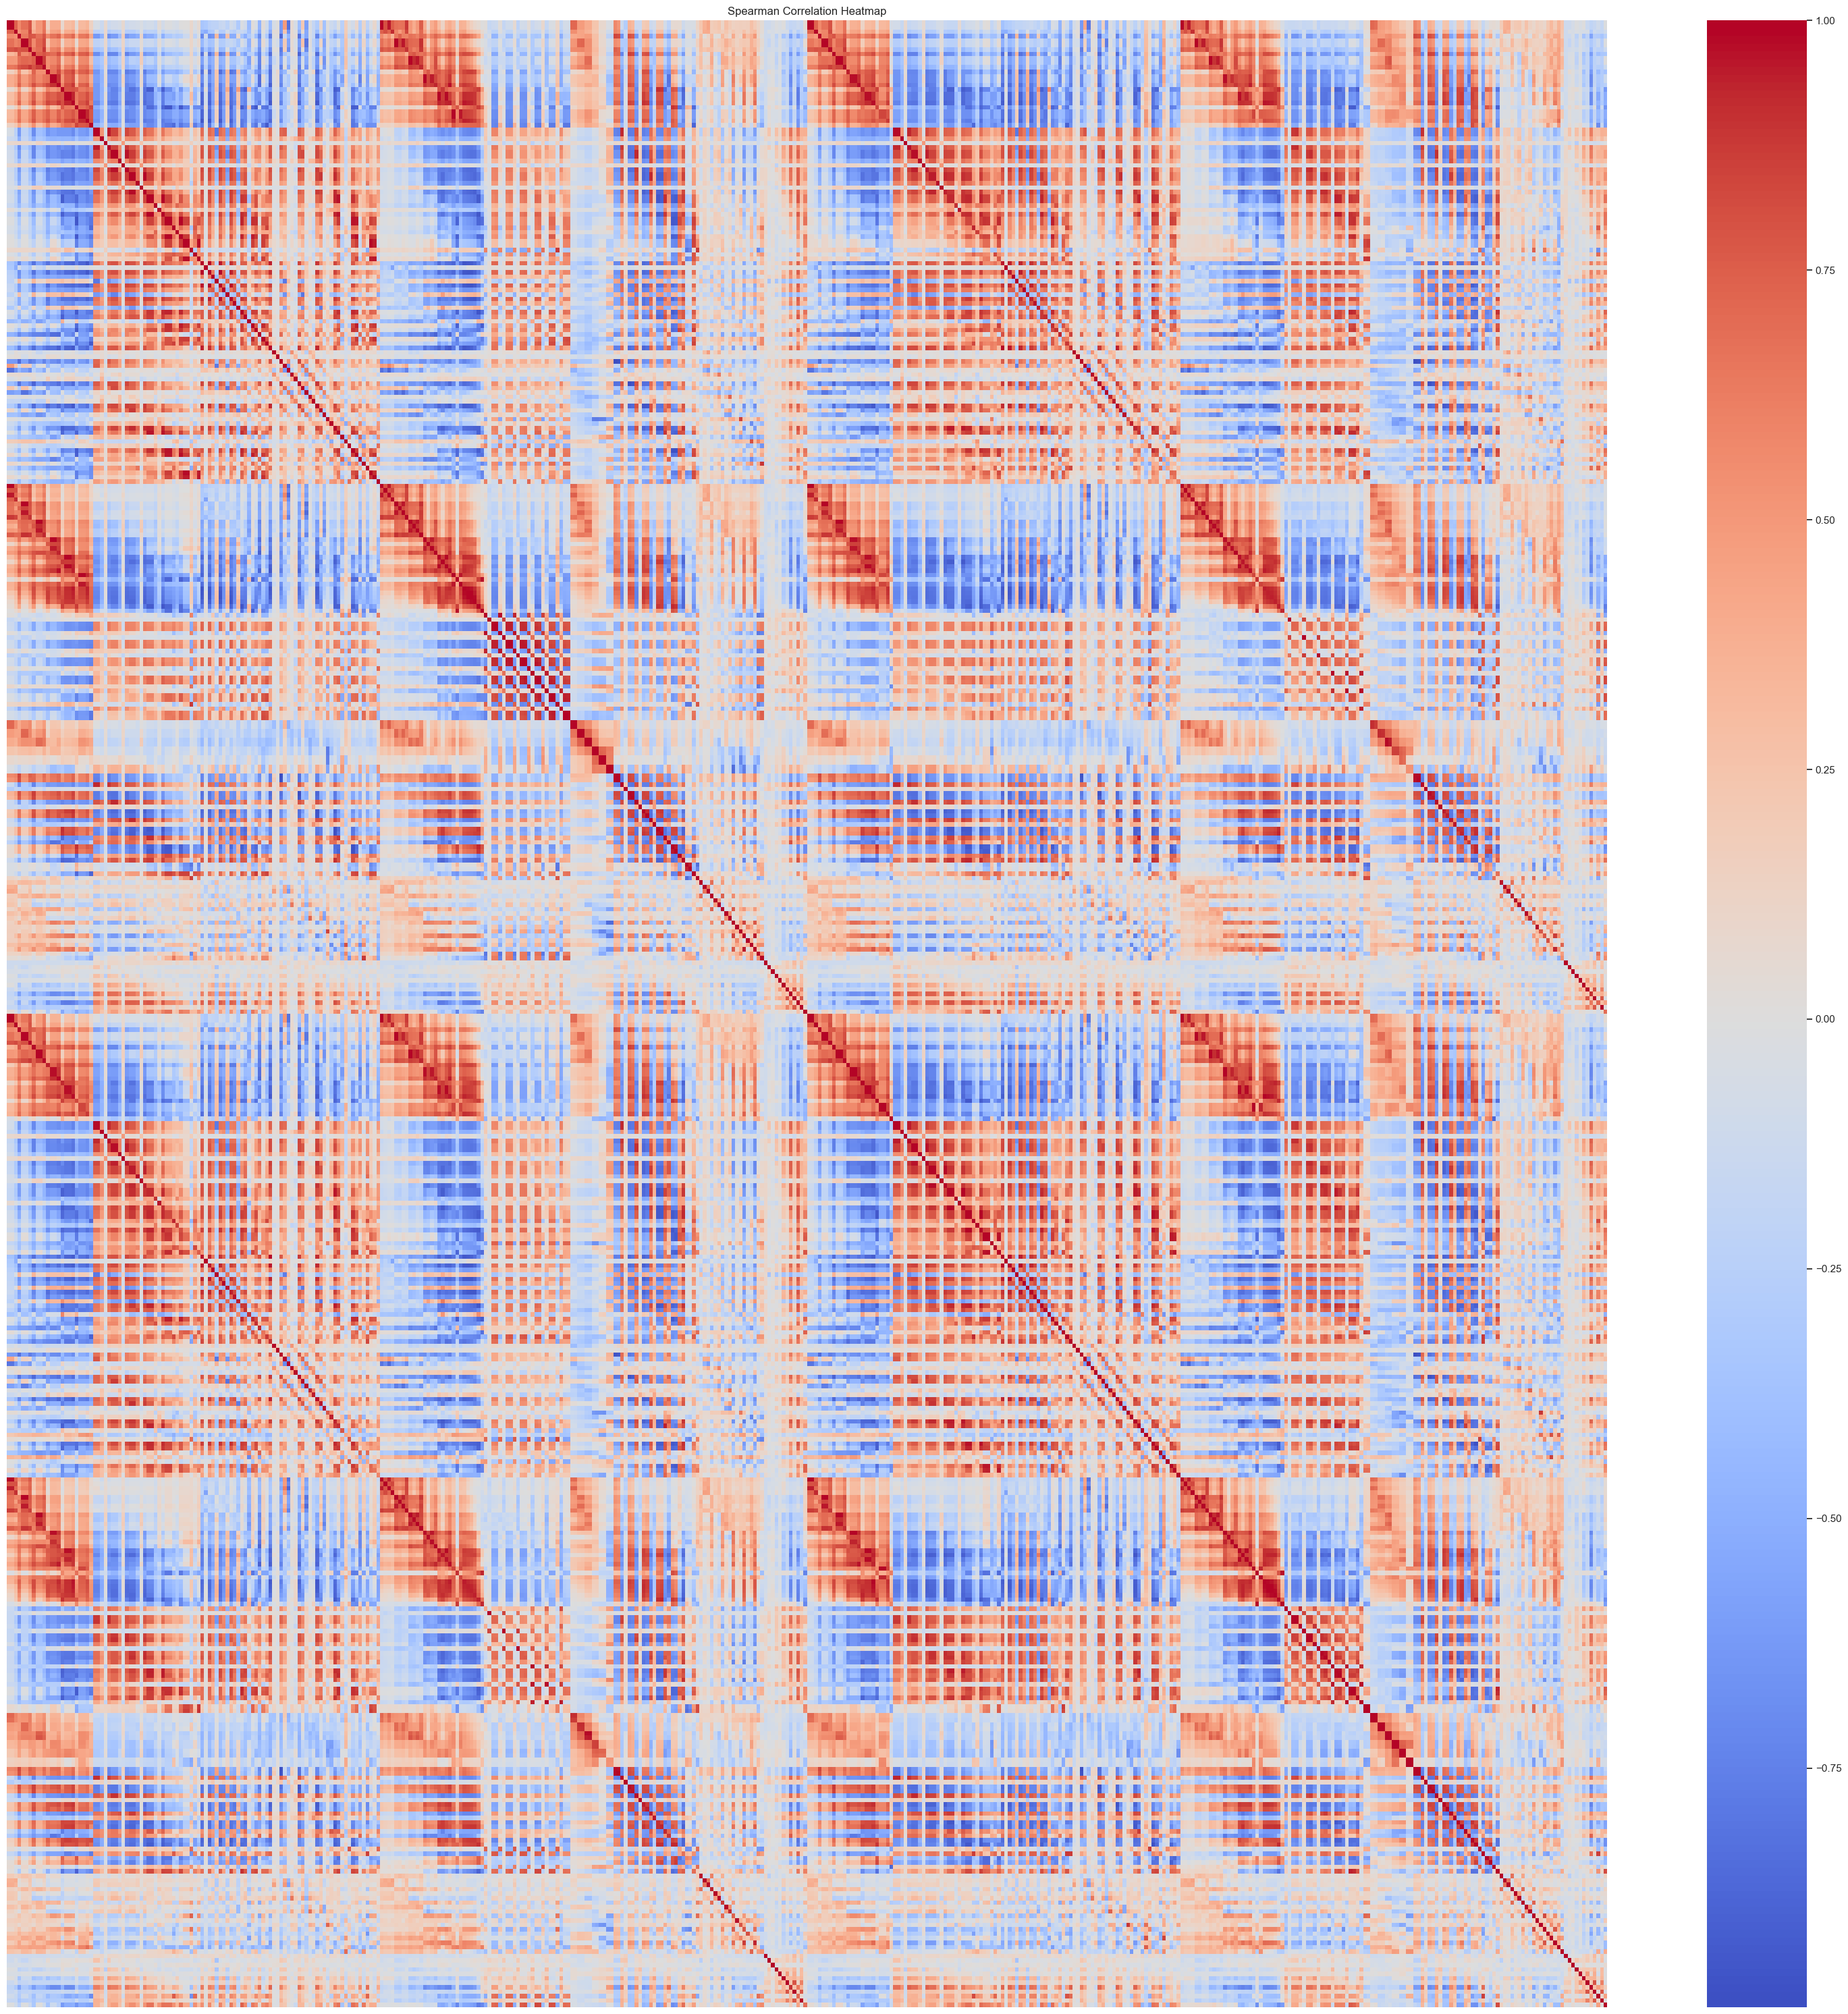

,feature_1,feature_2,correlation
0,returns_mean_5,returns_cumulative_5,1.0
1,volatility_std_5,volatility_variance_5,1.0
2,returns_mean_120_robust,momentum_cumulative_120_robust,1.0
3,returns_cumulative_120_robust,momentum_cumulative_120_robust,1.0
4,volatility_std_252,volatility_variance_252,1.0
5,returns_mean_252_robust,momentum_cumulative_252_robust,1.0
6,returns_cumulative_252_robust,momentum_cumulative_252_robust,1.0
7,volatility_std_120,volatility_variance_120,1.0
8,volatility_std_60,volatility_variance_60,1.0
9,volatility_std_20,volatility_variance_20,1.0


In [5]:
# Spearman rank correlation highlights monotonic redundancy while staying robust to heavy tails.
corr_spearman = X.corr(method="spearman")
abs_corr = corr_spearman.abs()
high_corr_pairs = extract_high_correlation_pairs(corr_spearman, threshold=0.85)

plot_matrix_heatmap(corr_spearman, title="Spearman Correlation Heatmap")
high_corr_pairs.head(25)

In [ ]:
# Mutual information captures nonlinear dependence that linear correlation can miss.
mi_matrix = compute_mutual_information_matrix(X)
mi_norm = mi_matrix / mi_matrix.to_numpy().max()
mi_norm = pd.DataFrame(mi_norm, index=X.columns, columns=X.columns)

plot_matrix_heatmap(mi_norm, title="Normalized Mutual Information Heatmap", center=None)
mi_norm.iloc[:10, :10]

In [ ]:
# Distances transform similarity into a clustering-ready representation.
dist_corr = 1.0 - abs_corr
dist_corr = ((dist_corr + dist_corr.T) / 2.0).clip(lower=0.0)
np.fill_diagonal(dist_corr.values, 0.0)

dist_mi = 1.0 - mi_norm
dist_mi = ((dist_mi + dist_mi.T) / 2.0).clip(lower=0.0)
np.fill_diagonal(dist_mi.values, 0.0)

linkage_corr = plot_feature_dendrogram(dist_corr, title="Feature Dendrogram (Correlation Distance)")

In [ ]:
# Clustered heatmaps reorder features so redundancy blocks become visually obvious.
sns.clustermap(corr_spearman, method="ward", cmap="coolwarm", center=0, figsize=(18, 18), xticklabels=False, yticklabels=False)
plt.show()

sns.clustermap(mi_norm, method="ward", cmap="coolwarm", center=None, figsize=(18, 18), xticklabels=False, yticklabels=False)
plt.show()

In [ ]:
# Bundle the diagnostic artifacts for later inspection or downstream feature-pruning work.
redundancy_artifacts = {
    "corr_spearman": corr_spearman,
    "abs_corr": abs_corr,
    "high_corr_pairs": high_corr_pairs,
    "mi_matrix": mi_matrix,
    "mi_norm": mi_norm,
    "dist_corr": dist_corr,
    "dist_mi": dist_mi,
    "linkage_corr": linkage_corr,
}

high_corr_pairs